![Astrofisica Computacional](../../new_logo.png)

# Computational Astrophysics – Advanced Exercises

## Dr. rer. nat. Jose Ivan Campos Rozo<sup>1,2</sup>

1. Astronomical Institute of the Czech Academy of Sciences\
   Department of Solar Physics\
   Ondřejov, Czec Republic

2. Observatorio Astronómico Nacional\
   Facultad de Ciencias\
   Universidad Nacional de Colombia

e-mail: jicamposr@unal.edu.co & rozo@asu.cas.cz)

### Applied Exercise Set: Numerical Differentiation in Computational Astrophysics

1. Mathematical Foundation: Finite Difference Refresher

Numerical differentiation serves as the essential bridge between theoretical physics—often expressed as continuous differential equations—and the discrete datasets obtained through observations or high-performance simulations. In computational astrophysics, we approximate derivatives by constructing "stencils" that sample the function at discrete grid points.

While these formulas can be derived via Lagrange Interpolation (approximating the function with a polynomial that passes through specific data points), they are most commonly conceptualized using Taylor Series Expansions. By discretizing the domain into a constant grid spacing h (the interval between samples), we can define the following first-order derivative approximations:

Method Name	Discrete Formula ($f'_i \approx$)	Truncation Error\
Forward Difference $(D_+)	\frac{f_{i+1} - f_i}{h}	O(h)$\
Backward Difference $(D_-)	\frac{f_i - f_{i-1}}{h}	O(h)$\
Centered Difference $(D_0)	\frac{f_{i+1} - f_{i-1}}{2h}	O(h^2)$

Note on Grid Spacing (h) and Symmetry: The parameter h represents the discretization step (e.g., $\Delta t$, $\Delta r$, or $\Delta D$). Note that the Centered Difference achieves a higher order of accuracy ($O(h^2)$) than one-sided methods. This occurs because the symmetry of the centered stencil causes the $h^1$ error terms in the Taylor expansion to cancel out exactly, leaving the $h^2$ term as the leading order of error.


--------------------------------------------------------------------------------


2. Exercise 1: Pulsar Timing and Orbital Acceleration

Context: Pulsars are highly magnetized, rotating neutron stars. By analyzing the Doppler shift in their pulse arrival times, we can measure their line-of-sight velocity $v(t)$. In a binary system, the rate of change of this velocity provides the orbital acceleration, $a(t) = \frac{dv}{dt}$.

Dataset: The following table provides 5 velocity points for a pulsar with a constant time step $h = 0.5$ seconds.


| Index (i) | Time $t$ (s) | Velocity $v$ (km/s) |
|---|---|---|
| 0 | 0.0 | 200.0 |
| 1 | 0.5 | 205.2 |
| 2 | 1.0 | 210.8 |
| 3 | 1.5 | 216.9 |
| 4 | 2.0 | 223.5 |




Tasks:

* Task A: Calculate the acceleration at the initial point ($t_0 = 0.0$ s) using the Forward Difference formula.
* Task B: Calculate the acceleration at the final point ($t_4 = 2.0$ s) using the Backward Difference formula.
* Task C: Calculate the acceleration at the interior point ($t_2 = 1.0$ s) using the Centered Difference formula.


--------------------------------------------------------------------------------


3. Exercise 2: Stellar Structure and Density Gradients

Context: In stellar modeling, hydrostatic equilibrium is dictated by the pressure gradient $\frac{dP}{dr}$. When simulating the interior of a star, we often encounter a physical boundary at the surface. At the outermost data point of a model, we cannot use centered or forward differences because there is no physical data "outside" the star's boundary. This constraint necessitates the use of one-sided, multi-point stencils to maintain high accuracy.

Dataset: Radius $r$ (in $10^3$ km) and Pressure $P$ (arbitrary units) with a step $h = 0.1 \times 10^3$ km.


| Index (i) | Radius r | Pressure P |
|---|---|---|
| 0 | 1.0 | 10.00 |
| 1 | 1.1 | 9.15 |
| 2 | 1.2 | 8.20 |
| 3 | 1.3 | 7.12 |
| 4 | 1.4 | 5.90 |


Task: Calculate the pressure gradient $\frac{dP}{dr}$ at the outermost radius ($r = 1.4$) using the Three-Point Second-Order Backward Difference formula ($D_{-2}$): $f'(x_i) \approx \frac{3f_i - 4f_{i-1} + f_{i-2}}{2h}$

Instructional Guidance: Substitute the values for $P_4$, $P_3$, and $P_2$ into the stencil. In your conclusion, explain why this $O(h^2)$ method is preferred over a simple $O(h)$ backward difference. Hint: Consider the convergence rate—how the error would scale if you were to reduce the step size h by a factor of 10.


--------------------------------------------------------------------------------


4. Exercise 3: Galactic Dynamics and Redshift Gradients

Context: By mapping the redshift $z$ of galaxies at various distances D within a cluster, astronomers can determine the velocity field and the rate of expansion within the cluster. We require both the first derivative $\frac{dz}{dD}$ and the second derivative $\frac{d^2z}{dD^2}$ (the gradient of the gradient) to model the cluster's mass distribution.

Dataset: Distance step $h = 2$ Mpc.


| Index (i) | Distance D (Mpc) | Redshift z |
|---|---|---|
| 0 | 10 | 0.0020 |
| 1 | 12 | 0.0035 |
| 2 | 14 | 0.0055 |
| 3 | 16 | 0.0080 |
| 4 | 18 | 0.0110 |



Tasks:

* Task A: Apply the Centered Difference formula to approximate the first derivative $\frac{dz}{dD}$ at the midpoint ($D = 14$ Mpc).
* Task B: Using the standard $O(h^2)$ centered formula for second derivatives (Reference: Table 2 of FiniteDifferences.pdf), approximate $\frac{d^2z}{dD^2}$ at the midpoint ($D = 14$ Mpc): $f''(x_i) \approx \frac{f_{i+1} - 2f_i + f_{i-1}}{h^2}$

Requirement: Show the step-by-step substitution of the values $z_1$, $z_2$, $z_3$ into the formulas below.


* Substitution for $\frac{dz}{dD}$: 
* Substitution for $\frac{d^2z}{dD^2}$: 


--------------------------------------------------------------------------------


5. Error Analysis and Consistency Discussion

As a numerical analyst, you must evaluate the fidelity of your discretization. Based on the provided source context, answer the following:

1. Theoretical Accuracy: Why is the Centered Difference method in Exercise 3 significantly more reliable than the Forward Difference used in Exercise 1? Reference the Taylor series truncation in your answer.
2. Convergence and Step Size: If the step size $h$ in the stellar model (Exercise 2) were halved, by what factor would the truncation error decrease for this second-order ($p=2$) method? Use the $O(h^p)$ relationship to justify your answer.
3. High-Fidelity Simulations: In simulations of galactic collisions or long-term planetary dynamics, "Mixed Differences" or "Approximations with more points" (such as the $O(h^4)$ coefficients $a_1=2/3$, $a_2=-1/12$ found in diferencias_compactas.pdf) are utilized. Explain why O(h) or O(h^2) methods are often insufficient for these specific astrophysical applications.


--------------------------------------------------------------------------------


6. Formula Key

The following stencils are derived from the standard Finite Difference coefficients used in computational physics.

- Forward Difference (First Order, $O(h)$) $f'(x_i) \approx \frac{f_{i+1} - f_i}{h}$

- Backward Difference (First Order, $O(h)$) $f'(x_i) \approx \frac{f_i - f_{i-1}}{h}$

- Centered Difference (Second Order, $O(h^2)$) $f'(x_i) \approx \frac{f_{i+1} - f_{i-1}}{2h}$

- Three-Point Backward Difference (Second Order, $D_{-2}$) Used for indices $i$, $i-1$, $i-2$: $f'(x_i) \approx \frac{3f_i - 4f_{i-1} + f_{i-2}}{2h}$

- Centered Second Derivative (Second Order, $O(h^2)$) Derived from Table 2, FiniteDifferences.pdf: $f''(x_i) \approx \frac{f_{i+1} - 2f_i + f_{i-1}}{h^2}$


## Ejercicio de clase, errores: 

Este ejercicio lo hice en clase con Martina y Alex, el código lo modifiqué solo para que no sea el mismo pero en esencia lo hicimos juntos 

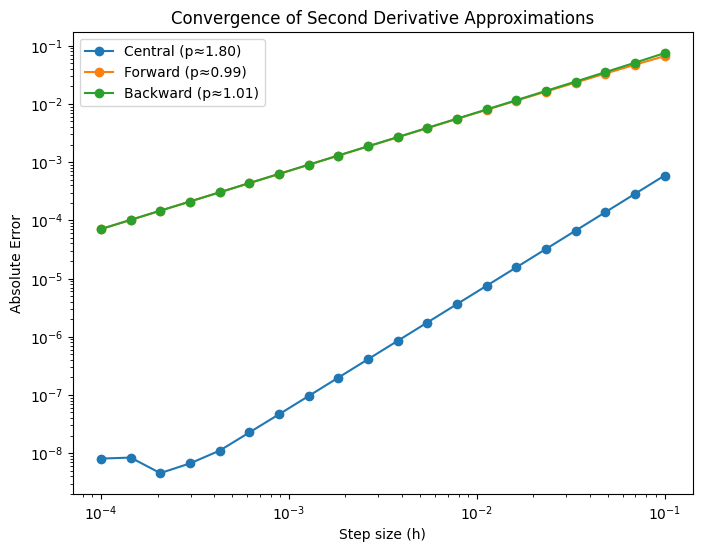

Estimated order for Central: 1.8040
Estimated order for Forward: 0.9940
Estimated order for Backward: 1.0054


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Funciones 

def second_derivative_central(f, x, h):
    return (f(x+h) - 2*f(x) + f(x-h)) / h**2

def second_derivative_forward(f, x, h):
    return (f(x+2*h) - 2*f(x+h) + f(x)) / h**2

def second_derivative_backward(f, x, h):
    return (f(x) - 2*f(x-h) + f(x-2*h)) / h**2


# Función de prueba

def f(x):
    return np.sin(x)

def exact_second_derivative(x):
    return -np.sin(x)


# Configuración numérica

x0 = np.pi / 4
h_values = np.logspace(-1, -4, 20)  # más continuo

methods = {
    "Central": second_derivative_central,
    "Forward": second_derivative_forward,
    "Backward": second_derivative_backward
}


# errores

errors = {}

for name, method in methods.items():
    numerical = method(f, x0, h_values)
    error = np.abs(numerical - exact_second_derivative(x0))
    errors[name] = error


# Cálculo del orden numérico (pendiente log-log)

orders = {}

for name in methods.keys():
    slope, _ = np.polyfit(np.log(h_values), np.log(errors[name]), 1)
    orders[name] = slope


#Gráfica 
plt.figure(figsize=(8,6))

for name in methods.keys():
    plt.loglog(h_values, errors[name], marker='o', label=f"{name} (p≈{orders[name]:.2f})")

plt.xlabel("Step size (h)")
plt.ylabel("Absolute Error")
plt.title("Convergence of Second Derivative Approximations")
plt.legend()
plt.grid(False, which="both")
plt.show()

# Mostrar órdenes estimados

for name in orders:
    print(f"Estimated order for {name}: {orders[name]:.4f}")

## Pulsar: 

Para entender como planetar las diferencias finitas correctamente lo que hago es pensar en donde puedo aplicarlas, en el inicio no puedo aplicar diferencias hacia atrás ni centradas porque no poseo datos suficientes, luego en el inicio sólo puedo aplicar diferencias hacia adelante, de manera similar funciona con el punto final, no puedo aplicar diferencias hacia adelante porque no poseo más datos, solo puedo hacia atrás, por último, para la parte intermedia lo optimo es aplicar la diferencia centrada. 

In [1]:
import numpy as np

# Datos
t = np.array([0.0, 0.5, 1.0, 1.5, 2.0])
v = np.array([200.0, 205.2, 210.8, 216.9, 223.5])

h = 0.5

# Forward Difference (t0)
a_forward = (v[1] - v[0]) / h

# Backward Difference (t4)
a_backward = (v[4] - v[3]) / h

# Centered Difference (t2)
a_centered = (v[3] - v[1]) / (2*h)

print("Acceleration at t0 (Forward):", a_forward, "km/s^2")
print("Acceleration at t4 (Backward):", a_backward, "km/s^2")
print("Acceleration at t2 (Centered):", a_centered, "km/s^2")

Acceleration at t0 (Forward): 10.399999999999977 km/s^2
Acceleration at t4 (Backward): 13.199999999999989 km/s^2
Acceleration at t2 (Centered): 11.700000000000017 km/s^2


## Estructura estelar: 

Para esto hallamos primero los valores necesarios: 

$$i = 4$$
$$P_i = 5.90 $$
$$P_{i-1} = 7.12 $$
$$P_{i-2} = 8.20 $$
$$h = 1.1-1.0 $$

In [3]:
import numpy as np

h = 0.1

P_i   = 5.90
P_im1 = 7.12
P_im2 = 8.20

dPdr = (3*P_i - 4*P_im1 + P_im2) / (2*h)

print("Gradiente de presión en r=1.4:", dPdr)

Gradiente de presión en r=1.4: -12.899999999999991


## Dinámica Galáctica: 

Primera derivada centrada: 
$$ \frac{f_{i+1}-f_{i-1}}{2h}$$
Segunda derivada centrada:
$$ \frac{f_{i+1}-2f_i +f_{i-1}}{h^2}$$

In [5]:
import numpy as np

# Datos
D = np.array([10, 12, 14, 16, 18])  # Mpc
z = np.array([0.0020, 0.0035, 0.0055, 0.0080, 0.0110])

h = 2  # paso en Mpc

# Índice del punto medio (D = 14 Mpc)
i = 2

# Primera derivada centrada O(h^2)
dz_dD = (z[i+1] - z[i-1]) / (2*h)

# Segunda derivada centrada O(h^2)
d2z_dD2 = (z[i+1] - 2*z[i] + z[i-1]) / (h**2)

print("Primera derivada dz/dD en D=14 Mpc:", dz_dD)
print("Segunda derivada d2z/dD2 en D=14 Mpc:", d2z_dD2)

Primera derivada dz/dD en D=14 Mpc: 0.0011250000000000001
Segunda derivada d2z/dD2 en D=14 Mpc: 0.00012500000000000022
